In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [60]:
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [62]:
df.duplicated().sum()

np.int64(763)

In [63]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 3577


In [64]:
df.describe()

,year,selling_price,km_driven
count,3577.000000,3.577000e+03,3577.000000
mean,2012.962538,4.739125e+05,69250.545709
std,4.251759,5.093018e+05,47579.940016
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,36000.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [65]:
print("Fuel types:")
print(df["fuel"].value_counts())

print("\nTransmission types:")
print(df["transmission"].value_counts())

print("\nSeller types:")
print(df["seller_type"].value_counts())

print("\nOwner types:")
print(df["owner"].value_counts())

Fuel types:
fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64

Transmission types:
transmission
Manual       3265
Automatic     312
Name: count, dtype: int64

Seller types:
seller_type
Individual          2832
Dealer               712
Trustmark Dealer      33
Name: count, dtype: int64

Owner types:
owner
First Owner             2218
Second Owner             978
Third Owner              289
Fourth & Above Owner      75
Test Drive Car            17
Name: count, dtype: int64


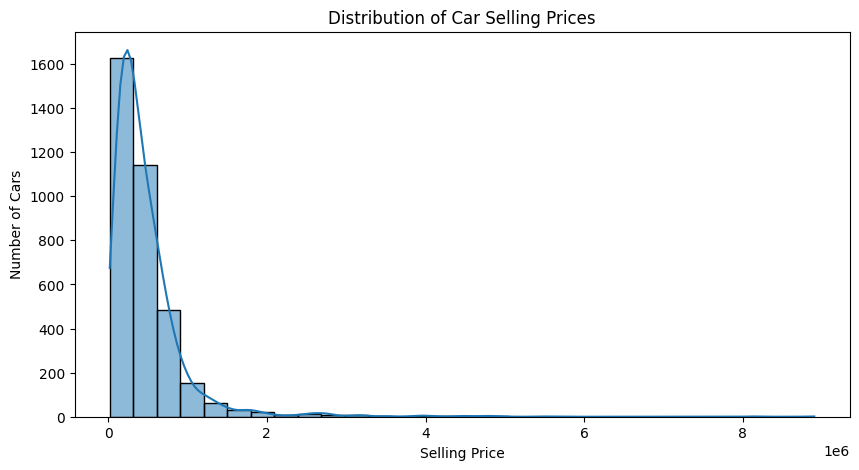

In [66]:
plt.figure(figsize=(10, 5))
sns.histplot(df["selling_price"], bins=30, kde=True)
plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

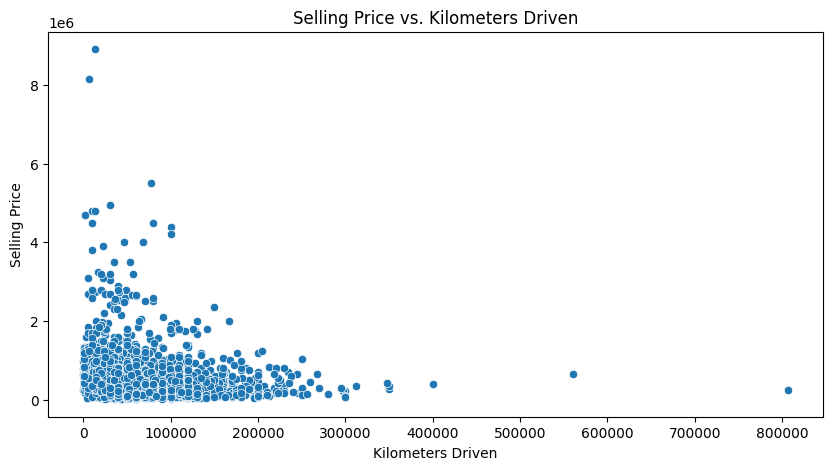

In [67]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="km_driven", y="selling_price")
plt.title("Selling Price vs. Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

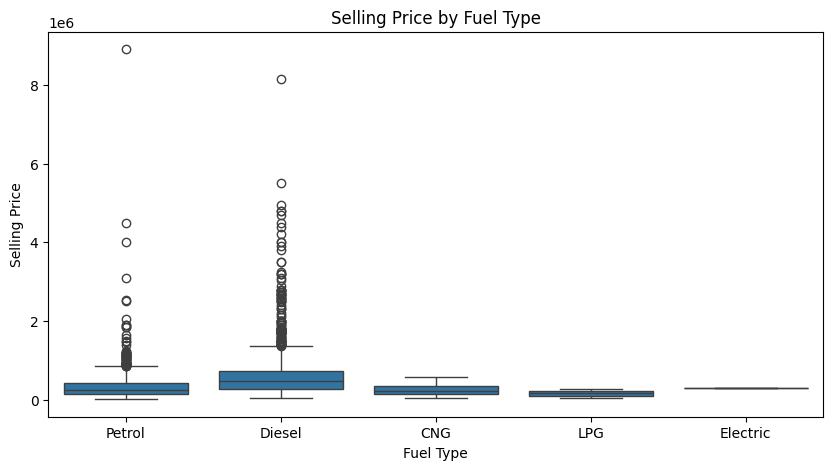

In [68]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="fuel", y="selling_price")
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

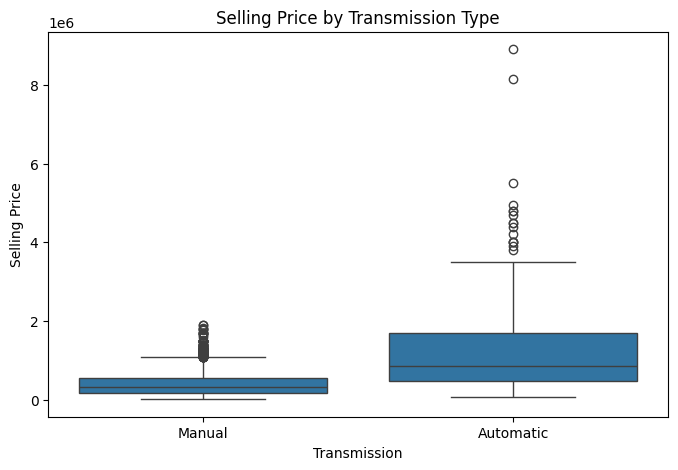

In [69]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="transmission", y="selling_price")
plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")
plt.show()

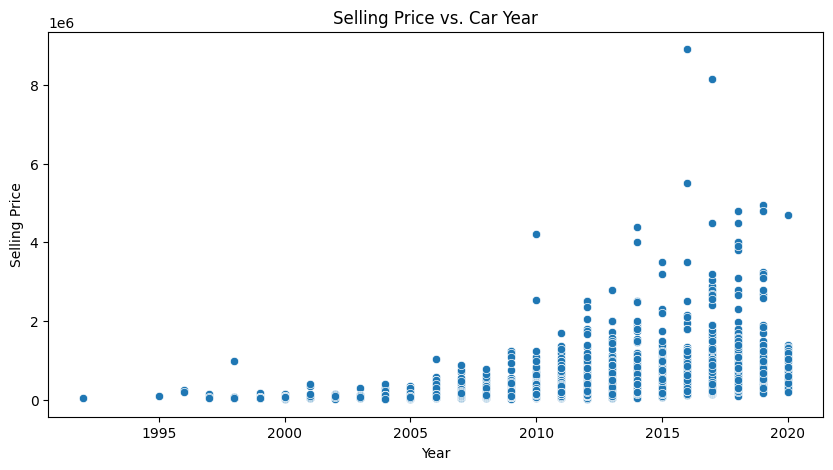

In [70]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="year", y="selling_price")
plt.title("Selling Price vs. Car Year")
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.show()

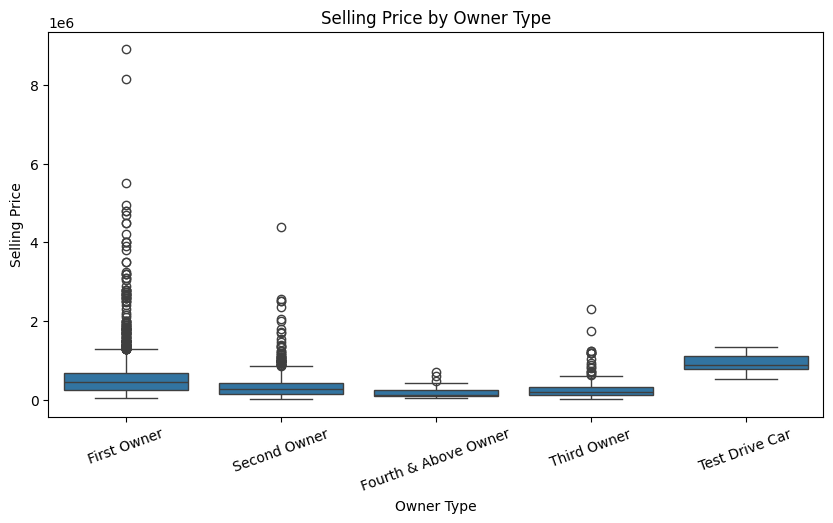

In [71]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="owner", y="selling_price")
plt.title("Selling Price by Owner Type")
plt.xlabel("Owner Type")
plt.ylabel("Selling Price")
plt.xticks(rotation=20)
plt.show()

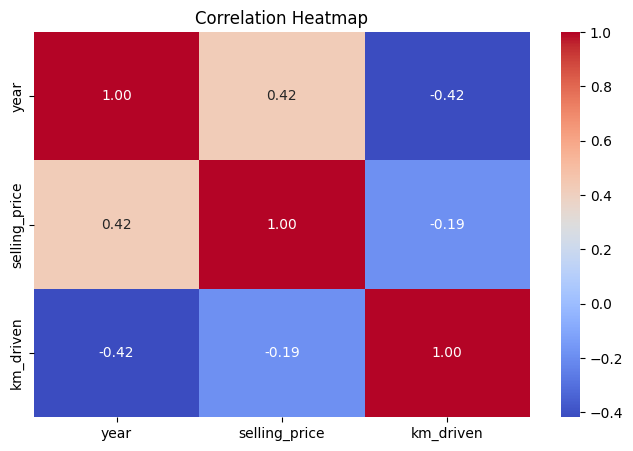

In [72]:
correlation = df[["year", "selling_price", "km_driven"]].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [73]:
from datetime import datetime

current_year = datetime.now().year

df["car_age"] = current_year - df["year"]

df[["year", "car_age"]].head()

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [74]:
df["brand"] = df["name"].str.split().str[0]

df[["name", "brand"]].head()

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda


In [75]:
X = df.drop(columns=["selling_price", "name"])
y = df["selling_price"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'car_age', 'brand']

Target:
selling_price


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2861, 8)
Testing data: (716, 8)


In [77]:
categorical_features = [
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "brand"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

print("Categorical columns:", categorical_features)

Categorical columns: ['fuel', 'seller_type', 'transmission', 'owner', 'brand']


In [78]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [79]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
MAE : 206391.0308805844
RMSE: 431742.0185066268
R²  : 0.4213540201867604


In [80]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [81]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
MAE : 159864.97987654127
RMSE: 368735.94465221575
R²  : 0.5779195324547102


In [82]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R2": [r2_linear, r2_rf]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,206391.030881,431742.018507,0.421354
1,Random Forest,159864.979877,368735.944652,0.577920


In [83]:
rf = random_forest_model.named_steps["model"]

feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("Top 10 Important Features:")
print(importance.head(10))

Top 10 Important Features:
cat__transmission_Manual       0.133566
remainder__km_driven           0.130885
remainder__year                0.117851
cat__transmission_Automatic    0.110460
remainder__car_age             0.109083
cat__fuel_Diesel               0.072687
cat__brand_Audi                0.052229
cat__fuel_Petrol               0.041266
cat__brand_Land                0.040273
cat__brand_Toyota              0.037104
dtype: float64


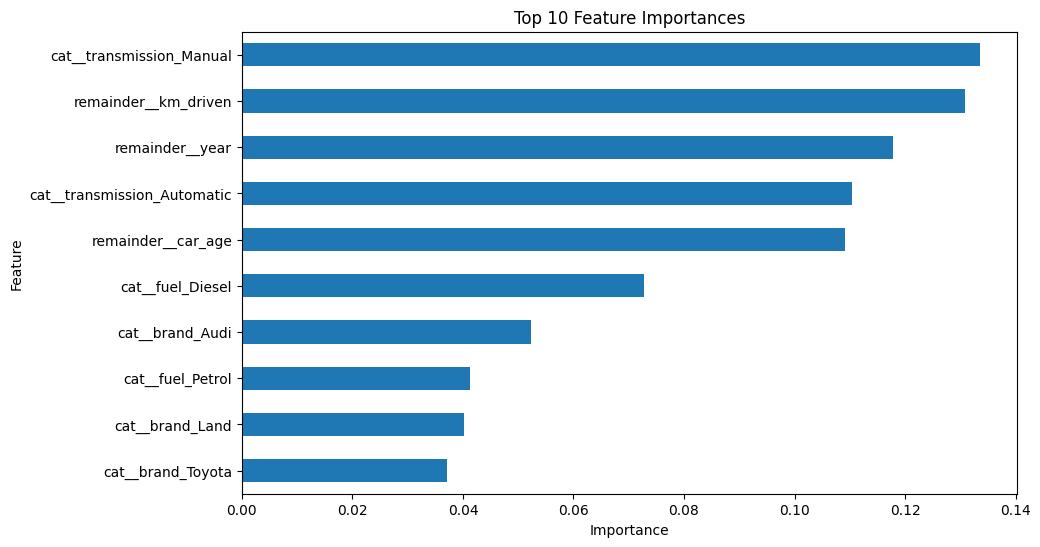

In [84]:
plt.figure(figsize=(10, 6))

importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

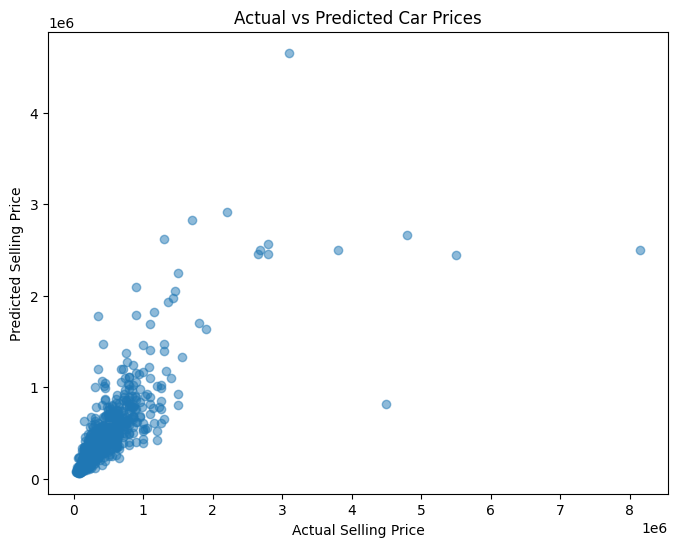

In [85]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [86]:
sample = X_test.iloc[[0]]

prediction = random_forest_model.predict(sample)[0]
actual = y_test.iloc[0]

print("Predicted Selling Price:", round(prediction, 2))
print("Actual Selling Price:", actual)

Predicted Selling Price: 568614.04
Actual Selling Price: 270000


In [87]:
print("CAR PRICE PREDICTION - PROJECT SUMMARY")
print("--------------------------------------")
print("Total records used:", len(df))
print("Features used:", X.shape[1])
print("Models trained: Linear Regression and Random Forest")
print("Evaluation metrics: MAE, RMSE and R²")
print("Best model: Random Forest (based on the evaluation results)")

CAR PRICE PREDICTION - PROJECT SUMMARY
--------------------------------------
Total records used: 3577
Features used: 8
Models trained: Linear Regression and Random Forest
Evaluation metrics: MAE, RMSE and R²
Best model: Random Forest (based on the evaluation results)


## Conclusion

In this project, a machine learning model was developed to predict used car selling prices.

The dataset was cleaned by removing duplicate records, and new features such as car age and car brand were created. Exploratory data analysis was performed using different visualizations to understand the relationship between car characteristics and selling prices.

Two regression models, Linear Regression and Random Forest Regression, were trained and evaluated using MAE, RMSE, and R².

The model with the better evaluation performance was selected as the preferred model for car price prediction. Feature importance analysis was also performed to identify the factors that contributed most to the predictions.